# Phase 1 — Ingest & EDA
Load all 15 city CSVs → clean → SQLite + Parquet, then explore the data before NLP.

**Run cells top to bottom.** Re-running is safe — tables are replaced, Parquet files overwritten.

**Outputs**
- `airbnb.db` — SQLite (listings + reviews, indexed)
- `parquet/listings_all.parquet`
- `parquet/reviews_raw.parquet`
- `parquet/reviews_with_features.parquet` — pre-joined for NLP


---
## 0. Imports & Config

In [74]:
import os, glob, re, sqlite3, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid", palette="muted")

# ── Paths — adjust BASE_DIR if your folder is elsewhere ───────────────────────
BASE_DIR    = os.path.expanduser("~/Desktop/MSIS/TEXT_MINING_NLP/Project/code2")
CSV_DIR     = os.path.join(BASE_DIR, "csv")
DB_PATH     = os.path.join(BASE_DIR, "airbnb.db")
PARQUET_DIR = os.path.join(BASE_DIR, "parquet")
os.makedirs(PARQUET_DIR, exist_ok=True)

# City to use for single-city inspection cells (change freely)
SAMPLE_CITY = "Denver_CO"

print("Base dir  :", BASE_DIR)
print("CSV dir   :", CSV_DIR, " — exists:", os.path.exists(CSV_DIR))
print("DB path   :", DB_PATH)
print("Parquet   :", PARQUET_DIR)


Base dir  : /Users/yawencao2024/Desktop/MSIS/TEXT_MINING_NLP/Project/code2
CSV dir   : /Users/yawencao2024/Desktop/MSIS/TEXT_MINING_NLP/Project/code2/csv  — exists: True
DB path   : /Users/yawencao2024/Desktop/MSIS/TEXT_MINING_NLP/Project/code2/airbnb.db
Parquet   : /Users/yawencao2024/Desktop/MSIS/TEXT_MINING_NLP/Project/code2/parquet


---
## 1. Configuration

In [75]:
# Listing columns kept for downstream analysis
# (URLs, thumbnails, calendar details etc. are dropped)
LISTING_KEEP_COLS = [
    "id", "name", "description",
    "host_id", "host_name", "host_response_time", "host_is_superhost",
    "host_has_profile_pic", "host_identity_verified",
    "neighbourhood_cleansed", "latitude", "longitude",
    "property_type", "room_type", "accommodates", "bedrooms", "amenities",
    "instant_bookable", "price",
    "number_of_reviews", "number_of_reviews_ltm",
    "review_scores_rating", "review_scores_accuracy",
    "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location",
    "review_scores_value",
    "reviews_per_month", "estimated_occupancy_l365d", "estimated_revenue_l365d",
    "minimum_nights", "availability_365", "host_listings_count",
    "listings_city",
]

# ⚠️  Always read these as str — 17-digit Airbnb IDs overflow float64 precision
LISTING_ID_COLS = ("id", "host_id")
REVIEW_ID_COLS  = ("id", "listing_id", "reviewer_id")

print("Config ready.")


Config ready.


---
## 2. Helper Functions

In [76]:
def read_csv(path: str, id_cols: tuple) -> pd.DataFrame:
    """Read CSV forcing ID columns to str — prevents float64 precision loss."""
    header = pd.read_csv(path, nrows=0).columns.tolist()
    dtype  = {c: str for c in id_cols if c in header}
    return pd.read_csv(path, low_memory=False, dtype=dtype if dtype else None)


def clean_listings(df: pd.DataFrame, city_tag: str) -> pd.DataFrame:
    """Strip IDs, deduplicate, slim columns, normalise booleans."""
    # Strip the whitespace in id column
    df = df.copy()
    for c in LISTING_ID_COLS:
        if c in df.columns:
            df[c] = df[c].str.strip()
    df = df.dropna(subset=["id"])
    
    # Remove duplicates based on listing id 
    n_before = len(df)
    df = df.drop_duplicates(subset=["id"], keep="first")
    if len(df) < n_before:
        print(f"  [{city_tag}] dropped {n_before - len(df)} duplicate listing IDs.")
    
    # Remove unwanted columns 
    df["city_tag"] = city_tag
    keep = [c for c in LISTING_KEEP_COLS if c in df.columns] + ["city_tag"]
    df = df[keep].copy()

    # Normalize the booleans features in the table

    for col in ["host_is_superhost", "host_has_profile_pic",
                "host_identity_verified", "instant_bookable"]:
        if col in df.columns:
            df[col] = df[col].map({"t": True, "f": False, True: True, False: False})
    return df

import re


def clean_reviews(df: pd.DataFrame, city_tag: str) -> pd.DataFrame:
    """Strip IDs, drop filler rows, keep meaningful comments."""
    df = df.copy()
    
    # Clean ID columns
    for c in REVIEW_ID_COLS:
        if c in df.columns:
            df[c] = df[c].str.strip()

    # Drop rows missing key data
    df = df.dropna(subset=["listing_id", "comments"])

    # Remove duplicate review IDs
    if "id" in df.columns:
        df = df.drop_duplicates(subset=["id"], keep="first")

    # Add city tag
    df["city_tag"] = city_tag

    # Clean comment text
    df["comments"] = df["comments"].astype(str).str.strip()

    # ✅ Drop ONLY single-letter comments
    df = df[~df["comments"].str.match(r"^[A-Za-z]$", na=False)]

    return df


def recover_malformed_reviews(df: pd.DataFrame) -> pd.DataFrame:
    """Recover review comments that ended up in 'listings_city' column due to CSV parsing issues."""
    df = df.copy()
    
    # Find rows where listing_id and comments are NaN, but listings_city has content starting with <br/>
    malformed_mask = (
        df['listing_id'].isna() & 
        df['comments'].isna() & 
        df['listings_city'].notna() & 
        df['listings_city'].astype(str).str.startswith('<br/>')
    )
    
    if malformed_mask.sum() > 0:
        # Move the content from listings_city to comments
        df.loc[malformed_mask, 'comments'] = df.loc[malformed_mask, 'listings_city']
        # Clear the listings_city for these rows
        df.loc[malformed_mask, 'listings_city'] = None
        print(f"  Recovered {malformed_mask.sum():,} malformed review rows by moving text from 'listings_city' to 'comments'.")
    
    return df


def parquet_safe(df: pd.DataFrame) -> pd.DataFrame:
    """Coerce object columns to StringDtype so pyarrow doesn't choke."""
    out = df.copy()
    for c in out.columns:
        if out[c].dtype == object:
            out[c] = out[c].astype("string")
    return out


print("Helper functions defined.")


Helper functions defined.


---
## 3. File Inventory
Verify all 15 cities have both files before touching any data.

In [77]:
listing_files = sorted(glob.glob(os.path.join(CSV_DIR, "listings_*.csv")))

inventory = []
for lpath in listing_files:
    city_tag = os.path.basename(lpath).replace("listings_", "").replace(".csv", "")
    rpath    = os.path.join(CSV_DIR, f"reviews_{city_tag}.csv")
    inventory.append({
        "city"          : city_tag,
        "listings_file" : "✅" if os.path.exists(lpath) else "❌",
        "reviews_file"  : "✅" if os.path.exists(rpath) else "❌",
        "listings_MB"   : round(os.path.getsize(lpath) / 1e6, 1),
        "reviews_MB"    : round(os.path.getsize(rpath) / 1e6, 1) if os.path.exists(rpath) else None,
    })

inventory_df = pd.DataFrame(inventory)
print(f"Cities found: {len(inventory_df)}")
inventory_df


Cities found: 15


,city,listings_file,reviews_file,listings_MB,reviews_MB
0,Austin_TX,✅,✅,28.10,166.70
1,Boston_MA,✅,✅,7.90,65.10
2,Cambridge_MA,✅,✅,3.40,22.70
3,Chicago_IL,✅,✅,22.30,150.50
4,Denver_CO,✅,✅,13.20,101.00
5,Hawaii_HI,✅,✅,87.10,509.60
6,LosAngeles_CA,✅,✅,112.00,536.30
7,Nashville_TN,✅,✅,26.30,226.10
8,NewOrleans_LA,✅,✅,18.90,161.60
9,NewYorkCity_NY,✅,✅,65.80,326.80


---
## 4. Single-City Inspection — Listings
Quick sanity check on one city before running the full ingest.  
Change `SAMPLE_CITY` in Section 0 to switch cities.


### 4.1 Shape & Sample

In [78]:
lpath = os.path.join(CSV_DIR, f"listings_{SAMPLE_CITY}.csv")
df_l  = read_csv(lpath, LISTING_ID_COLS)   # ← ID cols always as str

print(f"Shape: {df_l.shape[0]:,} rows × {df_l.shape[1]} columns")
df_l.head()


Shape: 4,910 rows × 80 columns


,listings_city,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,...,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,Denver,360,https://www.airbnb.com/rooms/360,20250929230429,2025-09-30,city scrape,Denver’s Peaceful Oasis for Travel Nurses & Nomads,Enjoy the famous Colorado weather and unplug in indoor & outdoor living. Our...,The cottage is located in the center of Lower Highlands (LOHI) next to the N...,https://a0.muscache.com/pictures/monet/Select-360/original/acb0aaaf-38db-44d...,666,https://www.airbnb.com/users/show/666,Jennifer,2008-07-08,"Denver, CO",We are artists and tinkerers.\r\n \r\nWe enjoy many activities here in Denve...,within an hour,100%,99%,t,https://a0.muscache.com/im/users/666/profile_pic/1259092920/original.jpg?aki...,https://a0.muscache.com/im/users/666/profile_pic/1259092920/original.jpg?aki...,Highland,3.00,4.00,...,120,2025-09-30,186,3,0,0,3,174,24186.00,2018-08-13,2025-08-18,4.98,4.97,4.95,4.99,4.99,4.98,4.90,2017-BFN-0002177,f,2,2,0,0,2.14
1,Denver,364,https://www.airbnb.com/rooms/364,20250929230429,2025-09-30,city scrape,Lodo / RiNo LOFT via airport train,"Modern 1,000 square foot loft in the heart of RiNo, the hottest neighborhood...","Ten brewpubs within walking distance, two great restaurants within two block...",https://a0.muscache.com/pictures/11766413/a2c5aaaf_original.jpg,783,https://www.airbnb.com/users/show/783,Jason,2008-07-11,"Denver, CO","I travel pretty frequently, I spend a lot of time in the mountains of Colora...",NaN,NaN,NaN,f,https://a0.muscache.com/im/users/783/profile_pic/1410556181/original.jpg?aki...,https://a0.muscache.com/im/users/783/profile_pic/1410556181/original.jpg?aki...,Five Points,1.00,1.00,...,358,2025-09-30,87,0,0,86,0,0,0.00,2009-05-18,2016-04-26,4.85,4.78,4.81,4.95,4.96,4.65,4.71,NaN,f,1,1,0,0,0.44
2,Denver,592,https://www.airbnb.com/rooms/592,20250929230429,2025-09-30,city scrape,private,"This room is in the basement. It does not have its own entrance, but is fai...",NaN,https://a0.muscache.com/pictures/ba522ff9-84c9-40a4-b4eb-61073b2b3d5f.jpg,933,https://www.airbnb.com/users/show/933,Jill,2008-07-21,"Denver, CO",I am friendly and I love meeting people from all over the world. I have re...,within an hour,100%,93%,t,https://a0.muscache.com/im/users/933/profile_pic/1321124670/original.jpg?aki...,https://a0.muscache.com/im/users/933/profile_pic/1321124670/original.jpg?aki...,North Park Hill,2.00,3.00,...,232,2025-09-30,201,25,4,56,11,175,8050.00,2009-02-21,2025-09-14,4.89,4.80,4.61,4.95,4.95,4.84,4.88,2021-BFN-0000578,f,1,0,1,0,0.99
3,Denver,686,https://www.airbnb.com/rooms/686,20250929230429,2025-09-30,city scrape,Alexandra's Queen Bed Room Long-term Rental Only,Thanks for visiting my Queen Bed Room for LONG-TERM rental! (31 nights minim...,"I love my Uptown neighborhood, which is within 2 to 3 miles of just about ev...",https://a0.muscache.com/pictures/108112/e6d5d3f8_original.jpg,990,https://www.airbnb.com/users/show/990,Alexandra,2008-07-23,"Denver, CO","Denver native, former teacher, musician, chaplain. Spent 4 years in Bolivia...",within a few hours,100%,80%,t,https://a0.muscache.com/im/pictures/user/c7c053dd-da41-4415-8331-c87978d7510...,https://a

### 4.2 Data Types

In [79]:
df_l.dtypes.to_frame("dtype").T


,listings_city,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,...,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
dtype,str,str,str,int64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,float64,float64,...,int64,str,int64,int64,int64,int64,int64,int64,float64,str,str,float64,float64,float64,float64,float64,float64,float64,str,str,int64,int64,int64,int64,float64


It's confirmed the id column in listing table is string text data type to avoid reading id as float number or in a scientifc notation format. 

### 4.3 Null Counts

In [80]:
null_l = pd.DataFrame({
    "null_count": df_l.isnull().sum(),
    "null_pct"  : (df_l.isnull().mean() * 100).round(1),
}).sort_values("null_pct", ascending=False)

null_l[null_l["null_count"] > 0].style.background_gradient(
    subset=["null_pct"], cmap="Oranges"
)


,null_count,null_pct
calendar_updated,4910,100.000000
neighbourhood_group_cleansed,4910,100.000000
neighborhood_overview,2172,44.200000
neighbourhood,2172,44.200000
host_about,1940,39.500000
license,1738,35.400000
host_response_rate,722,14.700000
host_response_time,722,14.700000
host_location,675,13.700000
review_scores_communication,608,12.400000


### 4.4 Duplicate ID Check

In [81]:
dupe_ids = df_l["id"].duplicated().sum()
print(f"Duplicate listing IDs : {dupe_ids}")
print(f"Unique IDs            : {df_l['id'].nunique():,}  /  {len(df_l):,} total rows")
if dupe_ids == 0:
    print("✅  No duplicates — ID column is clean.")
else:
    print("⚠️  Duplicates found. They will be dropped during ingest.")


Duplicate listing IDs : 0
Unique IDs            : 4,910  /  4,910 total rows
✅  No duplicates — ID column is clean.


### 4.5 Numeric Summary

In [82]:
numeric_cols = df_l.select_dtypes(include="number").columns.tolist()
df_l[numeric_cols].describe().T.style.background_gradient(subset=["mean"], cmap="Blues")


Exception ignored in: <function tqdm.__del__ at 0x1258d1260>
Traceback (most recent call last):
  File "/Users/yawencao2024/Desktop/MSIS/TEXT_MINING_NLP/Project/code2/venv/lib/python3.12/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/Users/yawencao2024/Desktop/MSIS/TEXT_MINING_NLP/Project/code2/venv/lib/python3.12/site-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


,count,mean,std,min,25%,50%,75%,max
scrape_id,4910.000000,20250929230429.003906,0.003907,20250929230429.000000,20250929230429.000000,20250929230429.000000,20250929230429.000000,20250929230429.000000
host_listings_count,4905.000000,24.556167,110.532331,1.000000,1.000000,2.000000,6.000000,890.000000
host_total_listings_count,4905.000000,47.761264,254.754883,1.000000,1.000000,2.000000,8.000000,2297.000000
neighbourhood_group_cleansed,0.000000,nan,nan,nan,nan,nan,nan,nan
latitude,4910.000000,39.742119,0.031679,39.624950,39.728243,39.748155,39.762538,39.847417
longitude,4910.000000,-104.976266,0.061599,-105.102804,-105.017105,-104.984857,-104.959497,-104.673817
accommodates,4910.000000,4.148676,2.656296,1.000000,2.000000,4.000000,6.000000,16.000000
bathrooms,4302.000000,1.524872,0.918542,0.000000,1.000000,1.000000,2.000000,17.000000
bedrooms,4828.000000,1.809859,1.126130,0.000000,1.000000,2.000000,2.000000,10.000000
beds,4299.000000,2.257967,1.679740,0.000000,1.000000,2.000000,3.000000,18.000000


### 4.6 Categorical Distributions

In [83]:
for col in ["room_type", "property_type", "host_is_superhost", "instant_bookable"]:
    if col in df_l.columns:
        print(f"\n── {col} ──")
        print(df_l[col].value_counts().head(10).to_string())



── room_type ──
room_type
Entire home/apt    4164
Private room        673
Shared room          49
Hotel room           24

── property_type ──
property_type
Entire home                  1591
Entire rental unit            897
Entire condo                  482
Private room in home          404
Entire guest suite            379
Entire townhouse              351
Entire guesthouse             288
Entire loft                    69
Private room in townhouse      69
Room in hotel                  51

── host_is_superhost ──
host_is_superhost
t    2747
f    2026

── instant_bookable ──
instant_bookable
f    3499
t    1411


### 4.7 Review Score Distribution

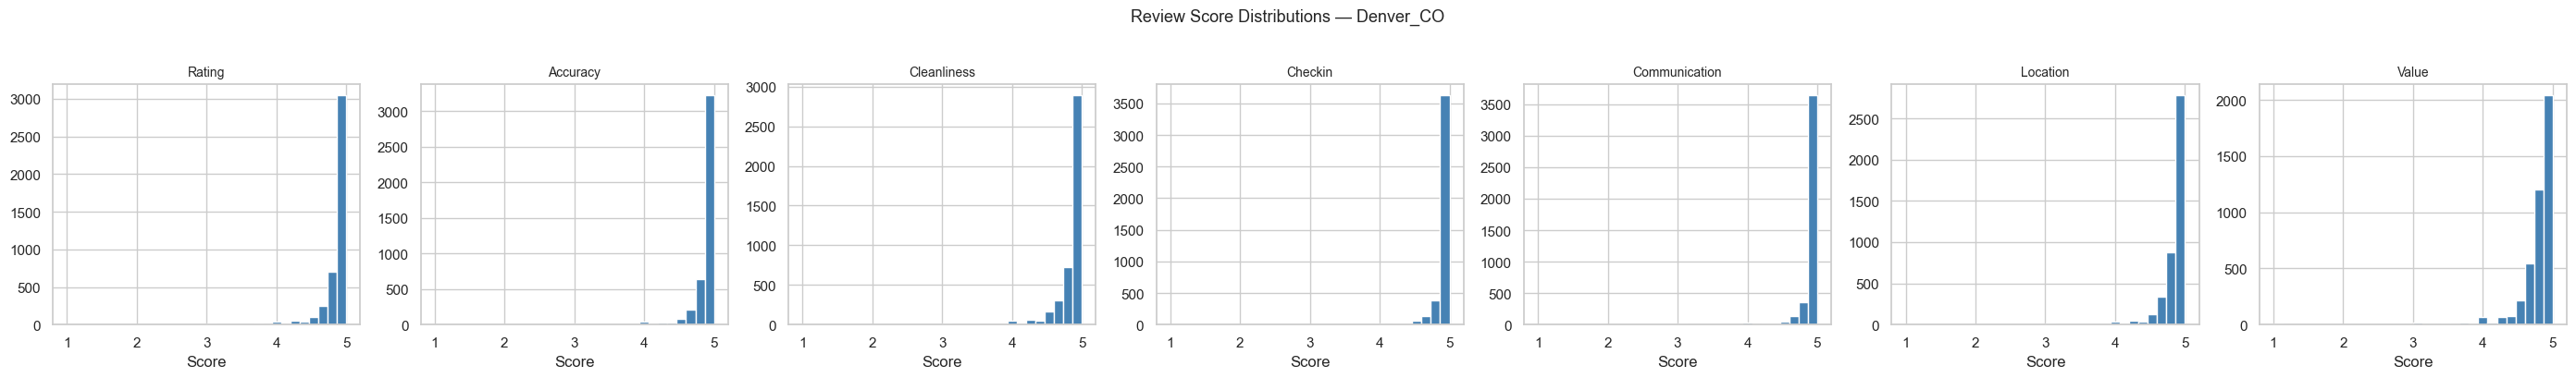

In [84]:
score_cols = [c for c in df_l.columns if c.startswith("review_scores_")]
if score_cols:
    fig, axes = plt.subplots(1, len(score_cols), figsize=(4 * len(score_cols), 4))
    if len(score_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, score_cols):
        df_l[col].dropna().hist(bins=30, ax=ax, color="steelblue", edgecolor="white")
        ax.set_title(col.replace("review_scores_", "").title(), fontsize=10)
        ax.set_xlabel("Score")
    fig.suptitle(f"Review Score Distributions — {SAMPLE_CITY}", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


---
## 5. Single-City Inspection — Reviews


### 5.1 Shape & Sample

In [85]:
rpath = os.path.join(CSV_DIR, f"reviews_{SAMPLE_CITY}.csv")
df_r  = read_csv(rpath, REVIEW_ID_COLS)   # ← ID cols always as str

# Drop Excel filler rows (only listing_city populated)
df_r = df_r.dropna(subset=["listing_id", "comments"])

print(f"Shape: {df_r.shape[0]:,} rows × {df_r.shape[1]} columns")
df_r.head()


Shape: 352,090 rows × 7 columns


,listings_city,listing_id,id,date,reviewer_id,reviewer_name,comments
0,Denver,360,307152490,2018-08-13,46723582,Madeleine,"This space was perfect! Great location, hosts, and accommodations. The garde..."
1,Denver,360,311601388,2018-08-21,68751664,Janelle,Hidden Gem in Denver. Magical Secret garden centrally located. Walking dista...
2,Denver,360,312497032,2018-08-23,57773484,Ziad,Amazing stay at one of the best kept AirBnB secrets in the world! Highly rec...
3,Denver,360,313089933,2018-08-24,11982181,Andrea,The cottage has a great setting with a garden and several outdoor areas to e...
4,Denver,360,314492150,2018-08-26,14620568,Iris,"Super cute place, very peaceful (loved the garden!)<br/>I only met Jennifer ..."


### 5.2 Null Counts

In [86]:
null_r = pd.DataFrame({
    "null_count": df_r.isnull().sum(),
    "null_pct"  : (df_r.isnull().mean() * 100).round(1),
}).sort_values("null_pct", ascending=False)

null_r[null_r["null_count"] > 0].style.background_gradient(
    subset=["null_pct"], cmap="Oranges"
)


,null_count,null_pct
reviewer_name,2,0.000000


### 5.3 Duplicate ID Check

In [49]:
if "id" in df_r.columns:
    dupe_r = df_r["id"].duplicated().sum()
    print(f"Duplicate review IDs  : {dupe_r}")
    print(f"Unique review IDs     : {df_r['id'].nunique():,}  /  {len(df_r):,} total rows")
    print("✅  Clean." if dupe_r == 0 else "⚠️  Duplicates will be dropped during ingest.")


Duplicate review IDs  : 0
Unique review IDs     : 352,090  /  352,090 total rows
✅  Clean.


### 5.4 Review Date Distribution

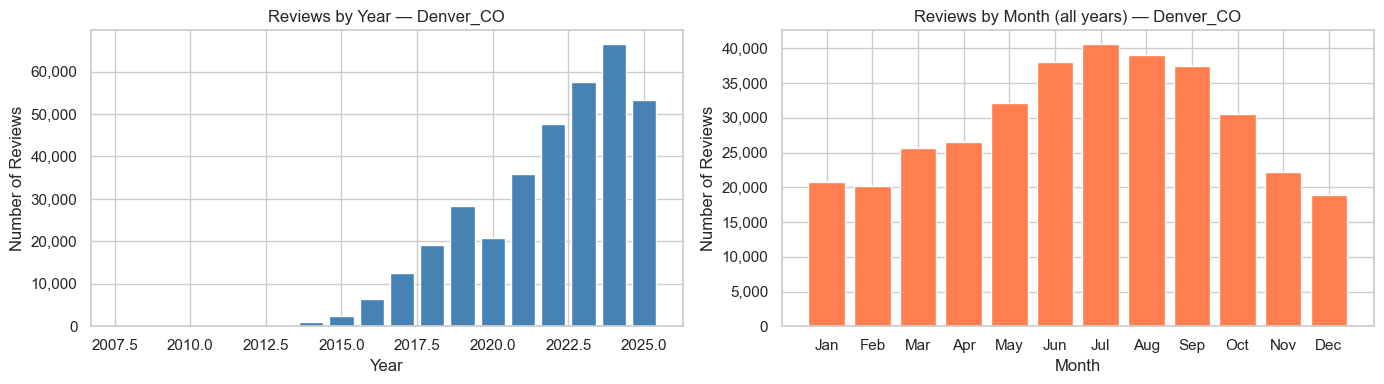

In [50]:
df_r["date"] = pd.to_datetime(df_r["date"], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# By year
yr = df_r["date"].dt.year.value_counts().sort_index()
axes[0].bar(yr.index, yr.values, color="steelblue", edgecolor="white")
axes[0].set_title(f"Reviews by Year — {SAMPLE_CITY}")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Reviews")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# By month (seasonality)
mo = df_r["date"].dt.month.value_counts().sort_index()
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
axes[1].bar([month_names[m-1] for m in mo.index], mo.values,
            color="coral", edgecolor="white")
axes[1].set_title(f"Reviews by Month (all years) — {SAMPLE_CITY}")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Number of Reviews")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()


### 5.5 Comment Length Distribution

count   352090.00
mean       221.20
std        208.20
min          1.00
25%         83.00
50%        164.00
75%        291.00
max       5565.00


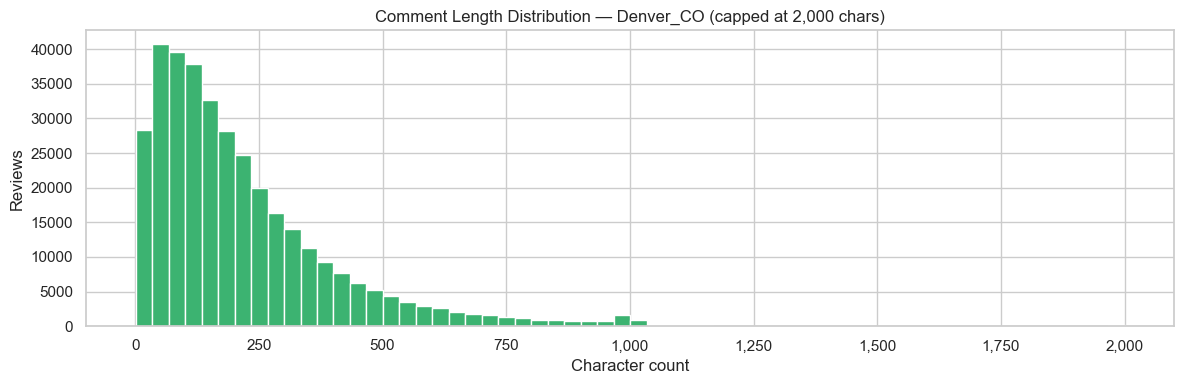

In [51]:
df_r["comment_len"] = df_r["comments"].astype(str).str.len()
print(df_r["comment_len"].describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(12, 4))
df_r["comment_len"].clip(upper=2000).hist(bins=60, ax=ax,
                                           color="mediumseagreen", edgecolor="white")
ax.set_title(f"Comment Length Distribution — {SAMPLE_CITY} (capped at 2,000 chars)")
ax.set_xlabel("Character count")
ax.set_ylabel("Reviews")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()


### 5.6 Join Coverage Check

In [52]:
matched   = df_r["listing_id"].isin(df_l["id"]).sum()
unmatched = len(df_r) - matched
print(f"Reviews matched to a listing : {matched:,}  ({matched/len(df_r)*100:.1f}%)")
print(f"Reviews with no match        : {unmatched:,}  ({unmatched/len(df_r)*100:.1f}%)")


Reviews matched to a listing : 352,090  (100.0%)
Reviews with no match        : 0  (0.0%)


### 5.7 Sample Comments

In [53]:
print(f"── 5 random review comments from {SAMPLE_CITY} ──\n")
for _, row in df_r[["comments"]].dropna().sample(5, random_state=42).iterrows():
    print(str(row["comments"])[:300])
    print()


── 5 random review comments from Denver_CO ──

Nice place

Super easy stay in a great location. Both pets were very friendly and a great bonus on checking in. Would stay again for sure.

Great house, great location! We stayed in Krista's house over Labor Day weekend - our preschoolers loved the easy access to parks and pools. Check out Stanley Marketplace for awesome food and ice cream. House was spotless and kitchen was well-stocked!

Loved Tahz’s place. Very responsive and helpful host. Property looked even better than the pictures.  Very convenient location for us as we wanted to be near most of what Denver had to offer. 5 stars ✨

Can’t say enough good things about this place - such a cozy little spot and so well decorated! The bed was super comfortable, the host was extremely attentive and easy to reach without being overbearing. Located in a good spot for walking to restaurants/little shops just a street over. Not a bad dri



---
## 6. All-City Summary Report (Before Ingest)
Loop through all 15 cities and build a side-by-side comparison for both listings and reviews.  
This inspection step identifies data quality issues before concatenating.


In [87]:
all_cities_report = []

for lpath in tqdm(listing_files, desc="Scanning all cities"):
    city_tag = os.path.basename(lpath).replace("listings_", "").replace(".csv", "")
    rpath    = os.path.join(CSV_DIR, f"reviews_{city_tag}.csv")

    if not os.path.exists(rpath):
        print(f"  ⚠️  Missing reviews for {city_tag}")
        continue

    # Read listings
    df_l = read_csv(lpath, LISTING_ID_COLS)
    listing_rows = len(df_l)
    listing_dupes = df_l["id"].duplicated().sum()
    unique_listing_ids = df_l["id"].nunique()

    # Read reviews
    df_r = read_csv(rpath, REVIEW_ID_COLS)
    df_r = df_r.dropna(subset=["listing_id", "comments"])
    review_rows = len(df_r)
    review_dupes = df_r["id"].duplicated().sum() if "id" in df_r.columns else 0
    unique_review_ids = df_r["id"].nunique() if "id" in df_r.columns else 0

    # Join coverage
    matched = df_r["listing_id"].isin(df_l["id"]).sum()
    match_pct = (matched / len(df_r) * 100) if len(df_r) > 0 else 0

    all_cities_report.append({
        "city"                   : city_tag,
        "listing_rows"           : listing_rows,
        "listing_dup_ids"        : listing_dupes,
        "listing_unique_ids"     : unique_listing_ids,
        "review_rows"            : review_rows,
        "review_dup_ids"         : review_dupes,
        "review_unique_ids"      : unique_review_ids,
        "reviews_matched_%"      : round(match_pct, 1),
    })

report_df = pd.DataFrame(all_cities_report)
print(f"\n{'='*100}")
print("ALL CITIES SUMMARY REPORT")
print(f"{'='*100}\n")
print(report_df.to_string(index=False))
print(f"\n{'='*100}")

# Highlight any issues
print("\n⚠️  ISSUES DETECTED:\n")
has_issues = False

dup_listings = report_df[report_df["listing_dup_ids"] > 0]
if len(dup_listings) > 0:
    print(f"🔴 Listings with duplicate IDs:")
    print(dup_listings[["city", "listing_dup_ids", "listing_rows"]].to_string(index=False))
    has_issues = True

dup_reviews = report_df[report_df["review_dup_ids"] > 0]
if len(dup_reviews) > 0:
    print(f"\n🔴 Reviews with duplicate IDs:")
    print(dup_reviews[["city", "review_dup_ids", "review_rows"]].to_string(index=False))
    has_issues = True

low_match = report_df[report_df["reviews_matched_%"] < 95]
if len(low_match) > 0:
    print(f"\n🟡 Cities with <95% review-to-listing match:")
    print(low_match[["city", "reviews_matched_%"]].to_string(index=False))
    has_issues = True

if not has_issues:
    print("✅ No critical issues found — safe to proceed with ingest.\n")


Scanning all cities: 100%|██████████| 15/15 [00:35<00:00,  2.39s/it]


ALL CITIES SUMMARY REPORT

           city  listing_rows  listing_dup_ids  listing_unique_ids  review_rows  review_dup_ids  review_unique_ids  reviews_matched_%
      Austin_TX         10533                0               10533       588174               0             588174             100.00
      Boston_MA          3707                0                3706       215654               0             215654             100.00
   Cambridge_MA          1358                0                1358        76815               0              76815             100.00
     Chicago_IL          8661                0                8661       492297               0             492297             100.00
      Denver_CO          4910                0                4910       352090               0             352090             100.00
      Hawaii_HI         33458                0               33458      1408897               7            1408890             100.00
  LosAngeles_CA         45596     

***Problem Needs To Be Fixed:***

Fewer number of reviews have been imported due to the csv parsing issue. 

### 6.1 Detailed Duplicate Review IDs Analysis
Identify which specific review IDs are duplicated and show their occurrence patterns.

In [88]:
print("\n" + "="*100)
print("DETAILED DUPLICATE REVIEW ID ANALYSIS")
print("="*100 + "\n")

# Collect all review data with IDs
all_review_details = []
for lpath in listing_files:
    city_tag = os.path.basename(lpath).replace("listings_", "").replace(".csv", "")
    rpath    = os.path.join(CSV_DIR, f"reviews_{city_tag}.csv")
    
    if not os.path.exists(rpath):
        continue
    
    df_r = read_csv(rpath, REVIEW_ID_COLS)
    df_r = df_r.dropna(subset=["listing_id", "comments"])
    
    if "id" in df_r.columns:
        df_r["city"] = city_tag
        all_review_details.append(df_r[["id", "city", "listing_id", "date"]])

if all_review_details:
    combined_reviews = pd.concat(all_review_details, ignore_index=True)
    
    # Find duplicated review IDs
    dup_mask = combined_reviews["id"].duplicated(keep=False)
    dup_ids = combined_reviews[dup_mask].sort_values("id")
    
    if len(dup_ids) > 0:
        print(f"🔴 Found {len(dup_ids)} review rows with duplicate IDs\n")
        print("Duplicate IDs and their occurrences:\n")
        
        # Group by ID to show where each duplicate appears
        dup_summary = (dup_ids.groupby("id")
                              .agg({"city": list, "listing_id": list, "date": list})
                              .reset_index())
        dup_summary["count"] = dup_summary["city"].apply(len)
        dup_summary = dup_summary.sort_values("count", ascending=False)
        
        for idx, row in dup_summary.iterrows():
            print(f"  Review ID: {row['id']} → appears {row['count']} times")
            for city, listing_id, date in zip(row['city'], row['listing_id'], row['date']):
                print(f"      • {city}: listing_id={listing_id}, date={date}")
        
        print("\n" + "-"*100)
        print("Full details of all duplicate review IDs:\n")
        print(dup_ids[["id", "city", "listing_id", "date"]].to_string(index=False))
    else:
        print("✅ No duplicate review IDs found across all cities!")
else:
    print("⚠️  No review data to analyze")


DETAILED DUPLICATE REVIEW ID ANALYSIS

🔴 Found 152 review rows with duplicate IDs

Duplicate IDs and their occurrences:

  Review ID: 1094349340375555075 → appears 2 times
      • SanFrancisco_CA: listing_id=1080417627227473963, date=2024-02-18
      • SanFrancisco_CA: listing_id=1080434868981403963, date=2024-02-18
  Review ID: 666735756233203244 → appears 2 times
      • Seattle_WA: listing_id=750913851705799630, date=2022-07-08
      • Seattle_WA: listing_id=969800834730550087, date=2022-07-08
  Review ID: 689896839269260114 → appears 2 times
      • Seattle_WA: listing_id=750913851705799630, date=2022-08-09
      • Seattle_WA: listing_id=969800834730550087, date=2022-08-09
  Review ID: 686338418792877972 → appears 2 times
      • Seattle_WA: listing_id=750913851705799630, date=2022-08-04
      • Seattle_WA: listing_id=969800834730550087, date=2022-08-04
  Review ID: 681238422767844808 → appears 2 times
      • Seattle_WA: listing_id=750913851705799630, date=2022-07-28
      • Seat

The 43 duplicates in the reviews table for Seattle,WA might due to some listing are related to each other, same reviews made by same reviewer at same time are associated with two listing id. We will remove the duplicates and randomly keep one version. 

---
## 7. Ingest — Load & Clean All Cities

Prepare a list of separate DataFrames. 

In [89]:
all_listings, all_reviews = [], []
clean_counts = []

# Loop over each city file 
for lpath in tqdm(listing_files, desc="Cities"):
    city_tag = os.path.basename(lpath).replace("listings_", "").replace(".csv", "")
    rpath    = os.path.join(CSV_DIR, f"reviews_{city_tag}.csv")  # find matching reviews file

    if not os.path.exists(rpath):
        print(f"  ⚠️  No reviews file for {city_tag} — skipping.")
        continue

    # Listings cleaning metrics
    df_l_raw = read_csv(lpath, LISTING_ID_COLS)
    listing_rows_raw = len(df_l_raw)
    listing_dup_removed = int(df_l_raw["id"].duplicated().sum())
    df_l_city = clean_listings(df_l_raw, city_tag)
    listing_rows_clean = len(df_l_city)
    all_listings.append(df_l_city)

    # Reviews cleaning metrics
    df_r_raw = read_csv(rpath, REVIEW_ID_COLS)
    df_r_raw = recover_malformed_reviews(df_r_raw)  # Recover comments from listings_city
    review_rows_raw = len(df_r_raw)
    df_r_missing = df_r_raw.dropna(subset=["listing_id", "comments"])
    missing_key_dropped = review_rows_raw - len(df_r_missing)
    df_r_quality = df_r_missing[df_r_missing["comments"].astype(str).str.strip().str.len() > 10]
    low_quality_dropped = len(df_r_missing) - len(df_r_quality)
    review_dup_removed = int(df_r_quality["id"].duplicated().sum()) if "id" in df_r_quality.columns else 0
    df_r_city = clean_reviews(df_r_raw, city_tag)
    review_rows_clean = len(df_r_city)
    all_reviews.append(df_r_city)

    clean_counts.append({
        "city"                  : city_tag,
        "listing_rows_raw"      : listing_rows_raw,
        "listing_rows_clean"    : listing_rows_clean,
        "listing_dup_removed"   : listing_dup_removed,
        "review_rows_raw"       : review_rows_raw,
        "missing_key_dropped"   : missing_key_dropped,
        "low_quality_dropped"   : low_quality_dropped,
        "review_dup_removed"    : review_dup_removed,
        "review_rows_clean"     : review_rows_clean,
        "review_rows_removed"   : review_rows_raw - review_rows_clean,
    })

print(f"\nLoaded {len(all_listings)} cities.")

summary_df = pd.DataFrame(clean_counts)
summary_df = summary_df[[
    "city",
    "listing_rows_raw",
    "listing_rows_clean",
    "listing_dup_removed",
    "review_rows_raw",
    "missing_key_dropped",
    "low_quality_dropped",
    "review_dup_removed",
    "review_rows_clean",
    "review_rows_removed",
]]

print("\nSummary of cleaning and drop counts per city:")
print(summary_df.to_string(index=False))

total_row = pd.DataFrame([{
    "city"                : "TOTAL",
    "listing_rows_raw"    : summary_df["listing_rows_raw"].sum(),
    "listing_rows_clean"  : summary_df["listing_rows_clean"].sum(),
    "listing_dup_removed" : summary_df["listing_dup_removed"].sum(),
    "review_rows_raw"     : summary_df["review_rows_raw"].sum(),
    "missing_key_dropped" : summary_df["missing_key_dropped"].sum(),
    "low_quality_dropped" : summary_df["low_quality_dropped"].sum(),
    "review_dup_removed"  : summary_df["review_dup_removed"].sum(),
    "review_rows_clean"   : summary_df["review_rows_clean"].sum(),
    "review_rows_removed" : summary_df["review_rows_removed"].sum(),
}])

print("\nTotals:")
print(total_row.to_string(index=False))

Cities:   0%|          | 0/15 [00:00<?, ?it/s]

  Recovered 1,402 malformed review rows by moving text from 'listings_city' to 'comments'.


Cities:  13%|█▎        | 2/15 [00:03<00:20,  1.59s/it]

  Recovered 645 malformed review rows by moving text from 'listings_city' to 'comments'.


Cities:  20%|██        | 3/15 [00:03<00:11,  1.00it/s]

...

  Recovered 1,520 malformed review rows by moving text from 'listings_city' to 'comments'.


Cities:  93%|█████████▎| 14/15 [00:41<00:02,  2.55s/it]

  Recovered 1,229 malformed review rows by moving text from 'listings_city' to 'comments'.


Cities: 100%|██████████| 15/15 [00:43<00:00,  2.90s/it]


Loaded 15 cities.

Summary of cleaning and drop counts per city:
           city  listing_rows_raw  listing_rows_clean  listing_dup_removed  review_rows_raw  missing_key_dropped  low_quality_dropped  review_dup_removed  review_rows_clean  review_rows_removed
      Austin_TX             10533               10533                    0           589764                 1590                 7995                   0             588024                 1740
      Boston_MA              3707                3706                    0           216360                  706                 3755                   0             215578                  782
   Cambridge_MA              1358                1358                    0            77200                  385                 1327                   0              76781                  419
     Chicago_IL              8661                8661                    0           493319                 1022                 7426                   0     

---
## 7. Combine & Validate

In [90]:
df_listings = pd.concat(all_listings, ignore_index=True)
df_reviews  = pd.concat(all_reviews,  ignore_index=True)

# Cross-city dedup
for df_, key, label in [
    (df_listings, "id",  "listing"),
    (df_reviews,  "id",  "review"),
]:
    if key in df_.columns:
        n = len(df_)
        df_.drop_duplicates(subset=[key], keep="first", inplace=True)
        if len(df_) < n:
            print(f"Dropped {n - len(df_):,} cross-city duplicate {label} rows.")

# Reassign after in-place drop
df_listings = df_listings.reset_index(drop=True)
df_reviews  = df_reviews.reset_index(drop=True)

print(f"Listings : {len(df_listings):>8,} rows  |  {df_listings['city_tag'].nunique()} cities")
print(f"Reviews  : {len(df_reviews):>8,} rows  |  {df_reviews['city_tag'].nunique()} cities")


Dropped 2 cross-city duplicate listing rows.
Listings :  189,152 rows  |  15 cities
Reviews  : 9,272,268 rows  |  15 cities
Listings :  189,152 rows  |  15 cities
Reviews  : 9,272,268 rows  |  15 cities


Two rows in the concat table have been removed due to cross-city deduplication. In other words, one listing id has been found in two cities. The listing id showed first was kept. 

In [91]:
matched   = df_reviews["listing_id"].isin(df_listings["id"]).sum()
unmatched = len(df_reviews) - matched
print(f"Join coverage : {matched:,} / {len(df_reviews):,}  ({matched/len(df_reviews)*100:.2f}%)")
if unmatched:
    print(f"Unmatched     : {unmatched:,}  (listings outside the 15-city export or dropped duplicates)")


Join coverage : 9,270,886 / 9,272,268  (99.99%)
Unmatched     : 1,382  (listings outside the 15-city export or dropped duplicates)


---
## 8. All-City EDA

### 8.1 Listings per City

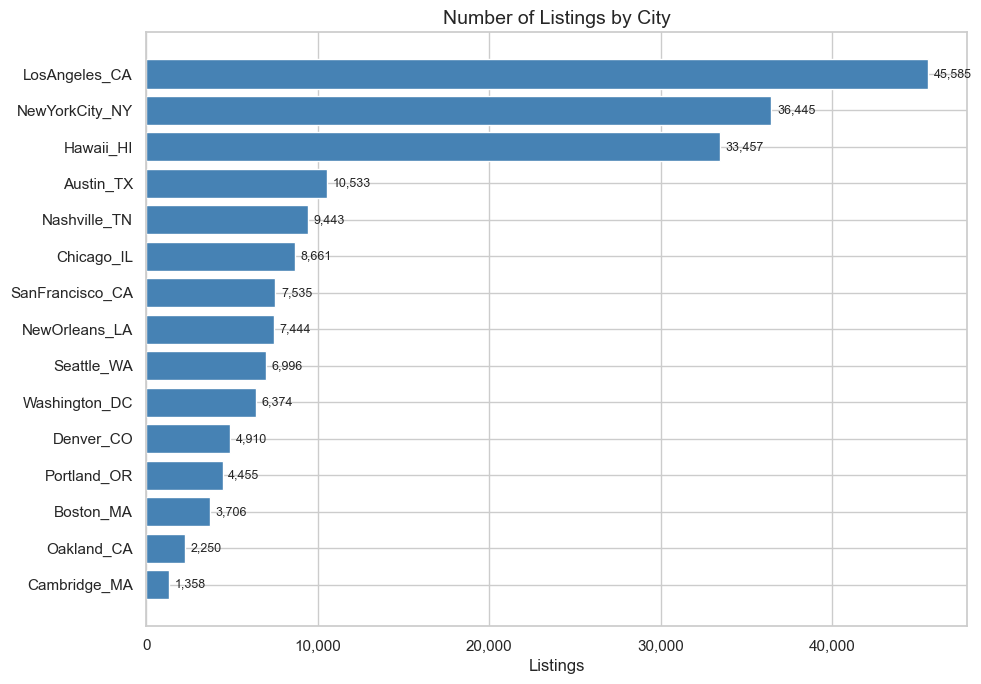

In [92]:
listing_counts = (df_listings.groupby("city_tag")
                              .size()
                              .reset_index(name="listings")
                              .sort_values("listings", ascending=True))

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(listing_counts["city_tag"], listing_counts["listings"],
               color="steelblue", edgecolor="white")
ax.bar_label(bars, labels=[f"{v:,}" for v in listing_counts["listings"]],
             padding=4, fontsize=9)
ax.set_title("Number of Listings by City", fontsize=14)
ax.set_xlabel("Listings")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()


### 8.2 Reviews per City

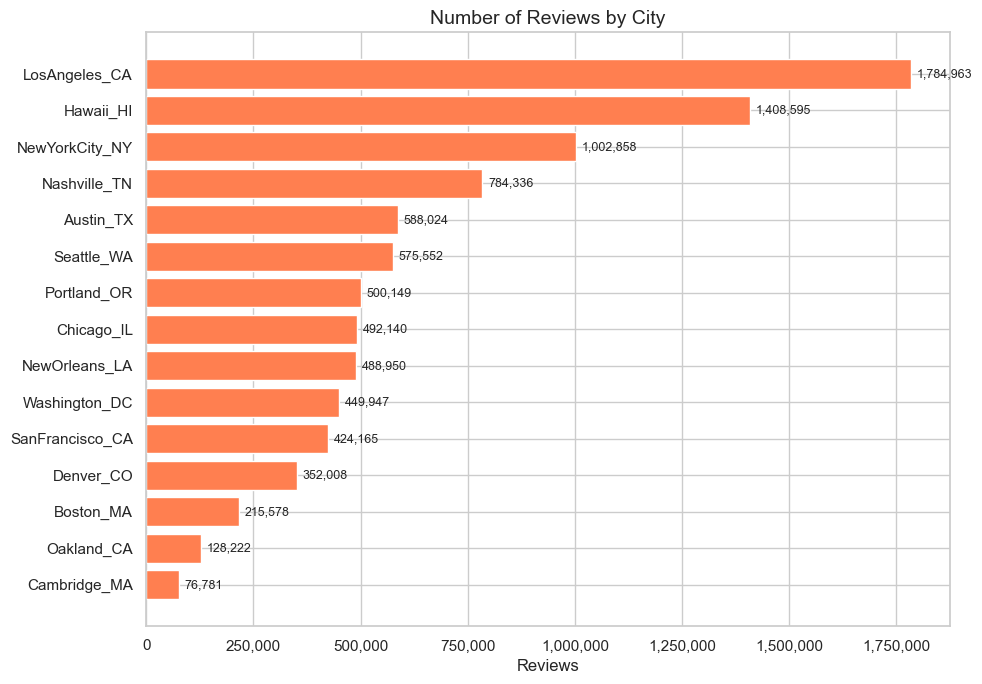

In [93]:
review_counts = (df_reviews.groupby("city_tag")
                            .size()
                            .reset_index(name="reviews")
                            .sort_values("reviews", ascending=True))

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(review_counts["city_tag"], review_counts["reviews"],
               color="coral", edgecolor="white")
ax.bar_label(bars, labels=[f"{v:,}" for v in review_counts["reviews"]],
             padding=4, fontsize=9)
ax.set_title("Number of Reviews by City", fontsize=14)
ax.set_xlabel("Reviews")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()


### 8.3 Reviews Over Time (All Cities)

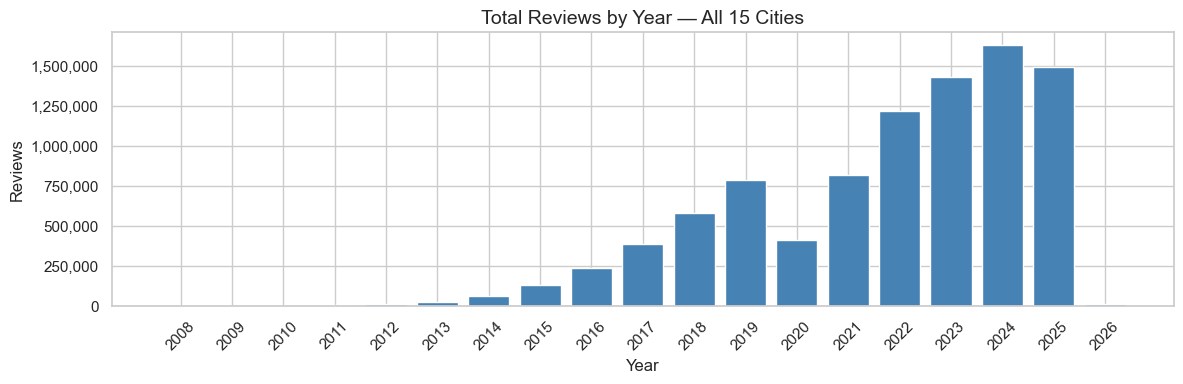

In [95]:
df_reviews["date"] = pd.to_datetime(df_reviews["date"], errors="coerce")
yearly = (df_reviews.dropna(subset=["date"])
                    .assign(year=lambda d: d["date"].dt.year)
                    .groupby("year").size()
                    .reset_index(name="reviews"))

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(yearly)), yearly["reviews"], color="steelblue", edgecolor="white")
ax.set_xticks(range(len(yearly)))
ax.set_xticklabels(yearly["year"].astype(int), rotation=45)
ax.set_title("Total Reviews by Year — All 15 Cities", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Reviews")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()


### 8.4 Avg Review Score by City

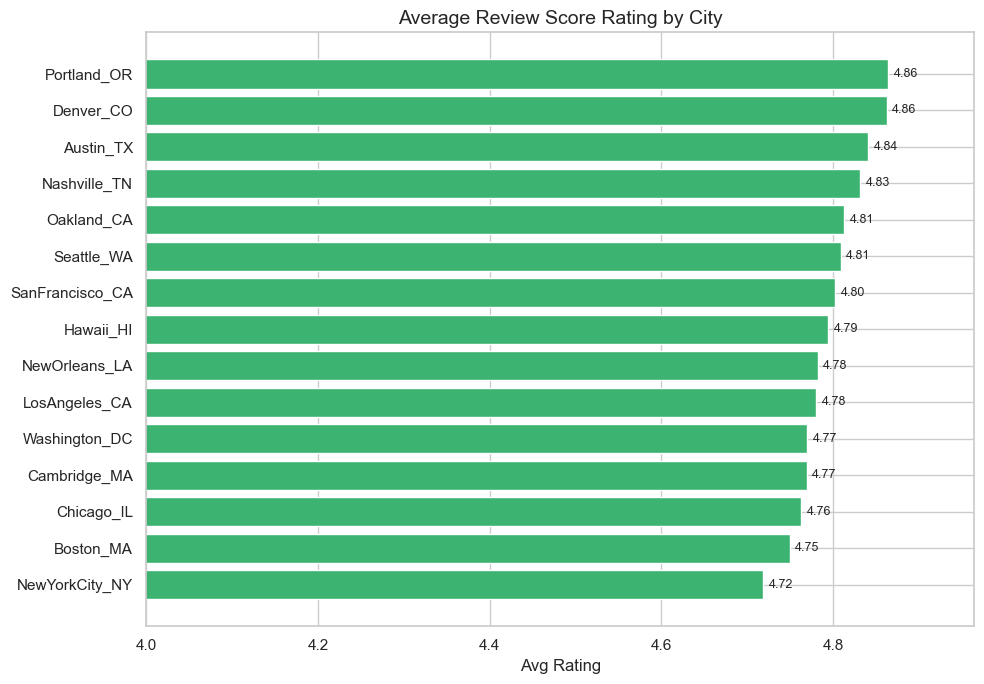

In [96]:
if "review_scores_rating" in df_listings.columns:
    avg_rating = (df_listings.groupby("city_tag")["review_scores_rating"]
                              .mean()
                              .reset_index()
                              .sort_values("review_scores_rating", ascending=True))

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(avg_rating["city_tag"], avg_rating["review_scores_rating"],
                   color="mediumseagreen", edgecolor="white")
    ax.bar_label(bars, labels=[f"{v:.2f}" for v in avg_rating["review_scores_rating"]],
                 padding=4, fontsize=9)
    ax.set_title("Average Review Score Rating by City", fontsize=14)
    ax.set_xlabel("Avg Rating")
    ax.set_xlim(4.0, avg_rating["review_scores_rating"].max() + 0.1)
    plt.tight_layout()
    plt.show()


### 8.5 Room Type Mix by City

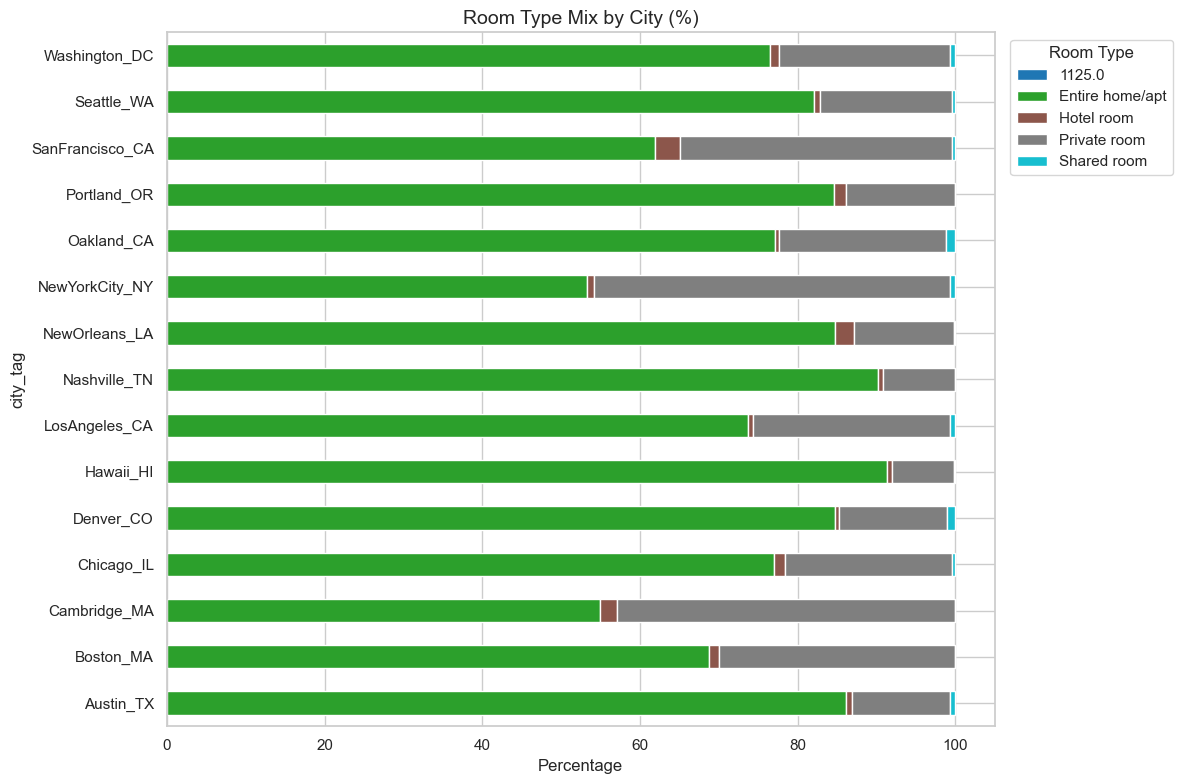

In [97]:
if "room_type" in df_listings.columns:
    room_mix = (df_listings.groupby(["city_tag", "room_type"])
                            .size()
                            .unstack(fill_value=0))
    room_mix_pct = room_mix.div(room_mix.sum(axis=1), axis=0) * 100

    room_mix_pct.plot(kind="barh", stacked=True, figsize=(12, 8),
                      colormap="tab10", edgecolor="white")
    plt.title("Room Type Mix by City (%)", fontsize=14)
    plt.xlabel("Percentage")
    plt.legend(title="Room Type", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


---
## 9. Write to SQLite

In [98]:
con = sqlite3.connect(DB_PATH)

df_listings.to_sql("listings", con, if_exists="replace", index=False)
df_reviews.to_sql("reviews",   con, if_exists="replace", index=False)

con.execute("CREATE INDEX IF NOT EXISTS idx_listings_id        ON listings(id)")
con.execute("CREATE INDEX IF NOT EXISTS idx_reviews_listing_id ON reviews(listing_id)")
con.execute("CREATE INDEX IF NOT EXISTS idx_reviews_city       ON reviews(city_tag)")
con.commit()
con.close()

print(f"SQLite DB written → {DB_PATH}")

# Quick verification
con = sqlite3.connect(DB_PATH)
print(pd.read_sql(
    'SELECT "listings" as tbl, COUNT(*) as rows FROM listings '
    'UNION ALL '
    'SELECT "reviews",         COUNT(*)          FROM reviews',
    con
).to_string(index=False))
con.close()


SQLite DB written → /Users/yawencao2024/Desktop/MSIS/TEXT_MINING_NLP/Project/code2/airbnb.db
     tbl    rows
listings  189152
 reviews 9272268


In [101]:
# Listings with most reviews
con = sqlite3.connect(DB_PATH)
pd.read_sql("""
    SELECT listing_id,city_tag, COUNT(*) as review_count 
    FROM reviews 
    GROUP BY listing_id 
    ORDER BY review_count DESC 
    LIMIT 10
""", con)

,listing_id,city_tag,review_count
0,858697692672545141,NewYorkCity_NY,4158
1,54227245,Nashville_TN,3425
2,42409434,LosAngeles_CA,3178
3,51619634,NewYorkCity_NY,2272
4,691676460109271194,NewYorkCity_NY,2166
5,37122502,NewYorkCity_NY,1987
6,34122310,Portland_OR,1847
7,565317486488599327,NewOrleans_LA,1839
8,750089121447866329,NewOrleans_LA,1771
9,1733052,Denver_CO,1711


---
## 10. Write to Parquet

In [99]:
# listings_all.parquet
lp = os.path.join(PARQUET_DIR, "listings_all.parquet")
parquet_safe(df_listings).to_parquet(lp, index=False)
print(f"Listings  → {lp}")

# reviews_raw.parquet
rp = os.path.join(PARQUET_DIR, "reviews_raw.parquet")
parquet_safe(df_reviews).to_parquet(rp, index=False)
print(f"Reviews   → {rp}")

# reviews_with_features.parquet — reviews joined with listing metadata
JOIN_COLS = [
    "id", "city_tag", "property_type", "room_type", "accommodates", "bedrooms",
    "host_is_superhost", "review_scores_rating", "review_scores_cleanliness",
    "review_scores_communication", "review_scores_location", "review_scores_value",
    "estimated_occupancy_l365d", "estimated_revenue_l365d", "neighbourhood_cleansed",
    "listings_city",
]
available = [c for c in JOIN_COLS if c in df_listings.columns]
df_joined = df_reviews.merge(
    df_listings[available].rename(columns={"id": "listing_id", "city_tag": "listing_city_tag"}),
    on="listing_id",
    how="left",
)
jp = os.path.join(PARQUET_DIR, "reviews_with_features.parquet")
parquet_safe(df_joined).to_parquet(jp, index=False)
print(f"Joined    → {jp}")
print(f"\n{len(df_joined):,} rows × {df_joined.shape[1]} columns in reviews_with_features")


Listings  → /Users/yawencao2024/Desktop/MSIS/TEXT_MINING_NLP/Project/code2/parquet/listings_all.parquet
Reviews   → /Users/yawencao2024/Desktop/MSIS/TEXT_MINING_NLP/Project/code2/parquet/reviews_raw.parquet
Reviews   → /Users/yawencao2024/Desktop/MSIS/TEXT_MINING_NLP/Project/code2/parquet/reviews_raw.parquet
Joined    → /Users/yawencao2024/Desktop/MSIS/TEXT_MINING_NLP/Project/code2/parquet/reviews_with_features.parquet

9,272,268 rows × 23 columns in reviews_with_features
Joined    → /Users/yawencao2024/Desktop/MSIS/TEXT_MINING_NLP/Project/code2/parquet/reviews_with_features.parquet

9,272,268 rows × 23 columns in reviews_with_features


---
## ✅ Phase 1 Complete
All outputs ready. Proceed to `02_nlp.ipynb` for the NLP pipeline.